# Diffusion Positive Control — Same Audit Tool, Applied to a Per-Mode Spectral Denoiser

**Why this notebook exists:** the Mamba-3 coupling-density audit (0.874 ± 0.014, essentially tied with attention's 0.878) closed that branch. Your main research bet was always diffusion, not Mamba — blurring diffusion (Inverse Heat Dissipation) is the one branch with an actual *proven theorem* behind it: in a fixed spectral basis (DCT / graph-Laplacian eigenbasis), the corruption operator and a per-mode gain-bank denoiser are both diagonal, with **zero cross-mode terms** (Theorem 1, Parseval scope factorization, in your proposal).

**This notebook is a positive control.** It re-runs the *exact same measurement tool* used against Mamba — unmodified, copy-pasted below — against a small model built the way your proposal's Hebbian-FNO / Wiener-gain denoiser is built: a bank of independent per-mode gains operating in a fixed spectral basis. If the theory is right, this should score close to **0**, the same way your "clean" sanity-check model did.

**Why bother confirming something you already proved on paper?** Two reasons:
1. It's cheap (this notebook took under an hour to build, reusing existing tooling).
2. It gives you one consistent instrument, run the same way, that shows Mamba failing and diffusion passing side by side — a strong, directly comparable figure for your eventual paper, rather than two different measurement methodologies that a reviewer could nitpick.

There's also a bonus section at the end that deliberately tries to *break* the clean result, by reproducing a degradation your own corpus already documented (Table 4 of the technical PIHL document: "Deep / nonlinear FNO stack" degrades from cosine 1.00 to 0.82 as depth and nonlinearity saturate). Including a test designed to fail, and being upfront about the result either way, is the same discipline your program has followed throughout.

## Step 0 — Setup
(Identical to the Mamba notebook.)

In [ ]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

Using device: cuda


## Config — same defaults as the Mamba notebook, for direct comparability

`C` = number of spectral modes / channels. `L` here is reinterpreted slightly from the Mamba notebook: instead of sequence timesteps, it's a batch of independent field snapshots (diffusion doesn't have a "previous token" the way a sequence model does — the diagonal claim is about cross-mode independence at a given noise level, not about time). The Jacobian machinery doesn't care either way; it just measures "does channel j affect channel i."

In [ ]:
C = 8         # number of spectral modes / channels (same as Mamba notebook)
L = 6         # batch of independent field snapshots (same as Mamba notebook)
N_SEEDS = 8   # random re-initializations to average over (same as Mamba notebook)

## Step 1 — The measurement tool (unchanged, copied verbatim from the Mamba notebook)

Same instrument, same math, same output convention. This is deliberate: for the comparison to mean anything, both experiments have to use the identical audit.

In [ ]:
def jacobian_coupling_density(model, x):
    """
    model: callable, x (L, C) -> y (L, C)
    x:     input tensor, shape (L, C)

    Returns:
      coupling_matrix: (C, C) numpy array, coupling_matrix[i, j] = total |dy_.,i / dx_.,j|
      density: float in [0, 1], fraction of coupling mass that is off-diagonal
    """
    x = x.clone().requires_grad_(True)
    J = torch.autograd.functional.jacobian(lambda inp: model(inp), x, create_graph=False)
    # J has shape (L, C, L, C):  J[t, i, t', j] = d y[t, i] / d x[t', j]
    coupling = J.abs().sum(dim=(0, 2))  # sum over both time/batch axes -> (C, C)
    coupling = coupling.detach().cpu().numpy()
    total = coupling.sum()
    diag_mass = np.trace(coupling)
    density = (total - diag_mass) / total if total > 0 else 0.0
    return coupling, density

def average_density(model_factory, n_seeds=N_SEEDS, L=L, C=C):
    """Builds a fresh random model + random input each seed, and averages the coupling density."""
    densities = []
    last_matrix = None
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        model = model_factory().to(device)
        model.eval()
        x = torch.randn(L, C, device=device)
        matrix, density = jacobian_coupling_density(model, x)
        densities.append(density)
        last_matrix = matrix
    return np.mean(densities), np.std(densities), last_matrix

def verdict(density):
    if density <= 0.15:
        return 'PASS  (<= 0.15) -- clean'
    elif density >= 0.4:
        return 'FAIL  (>= 0.4)  -- tangled like attention'
    else:
        return 'INCONCLUSIVE (between 0.15 and 0.4)'

## Step 2 — Baseline 1: Diagonal layer (floor, same as Mamba notebook)

Kept identical for calibration parity across both notebooks.

In [ ]:
class DiagonalLayer(nn.Module):
    def __init__(self, C):
        super().__init__()
        self.gain = nn.Parameter(torch.randn(C) * 0.5 + 1.0)
        self.bias = nn.Parameter(torch.randn(C) * 0.1)

    def forward(self, x):  # x: (L, C)
        return x * self.gain + self.bias

mean_d, std_d, mat_d = average_density(lambda: DiagonalLayer(C))
print(f'Diagonal layer coupling density: {mean_d:.3f} ± {std_d:.3f}   (expect ~0)')

Diagonal layer coupling density: 0.000 ± 0.000   (expect ~0)


## Step 3 — Baseline 2: Self-attention (ceiling, same as Mamba notebook)

In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, C):
        super().__init__()
        self.Wq = nn.Linear(C, C, bias=False)
        self.Wk = nn.Linear(C, C, bias=False)
        self.Wv = nn.Linear(C, C, bias=False)
        self.Wo = nn.Linear(C, C, bias=False)
        self.scale = C ** -0.5

    def forward(self, x):  # x: (L, C)
        L = x.shape[0]
        q, k, v = self.Wq(x), self.Wk(x), self.Wv(x)
        scores = (q @ k.transpose(-1, -2)) * self.scale
        mask = torch.triu(torch.ones(L, L, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))
        attn = torch.softmax(scores, dim=-1)
        out = attn @ v
        return self.Wo(out)

mean_a, std_a, mat_a = average_density(lambda: CausalSelfAttention(C))
print(f'Self-attention coupling density: {mean_a:.3f} ± {std_a:.3f}   (expect high, ~0.7-0.9)')

Self-attention coupling density: 0.878 ± 0.013   (expect high, ~0.7-0.9)


## Step 4 — Device under test #1: Linear per-mode spectral gain bank

This is the direct, literal implementation of your proposal's Bridge 1–2 construction: each spectral mode `k` gets its own independent gain `R_k`, applied as `y_k = R_k * x_k`. This is the Hebbian-FNO / Wiener-gain mechanism — the thing Theorem 1 claims has zero cross-mode terms by construction.

Architecturally this is the same *shape* as the diagonal baseline above — that's not a coincidence, it's the point. A diagonal gain bank **is** what "zero coupling" looks like structurally. What differs from the baseline is the framing: this model represents your actual denoiser mechanism, not just a sanity-check floor.

In [ ]:
class SpectralGainBank(nn.Module):
    """Per-mode linear gain, R_k * x_k -- the Hebbian-FNO / Wiener-gain denoiser core."""
    def __init__(self, C):
        super().__init__()
        self.R = nn.Parameter(torch.rand(C) * 0.8 + 0.2)  # per-mode gain, R_k

    def forward(self, x):  # x: (L, C), spectral coefficients
        return x * self.R

mean_g, std_g, mat_g = average_density(lambda: SpectralGainBank(C))
print(f'Spectral gain bank coupling density: {mean_g:.3f} ± {std_g:.3f}   (this is the main number to watch)')

Spectral gain bank coupling density: 0.000 ± 0.000   (this is the main number to watch)


## Step 5 — Device under test #2: Nonlinear per-mode denoiser

Your own Stage-A run 2 tested exactly this: a *nonlinear* per-mode score, `E[c0 | c] = tanh(alpha * c / sigma^2)`, and measured it stayed unbiased (gradient-alignment cosine 0.9985) even though the linear Wiener bridge does not cover nonlinear denoisers.

This reproduces that structure: each mode gets a nonlinear function of **its own input only** — no channel ever sees another channel's value. It's the diffusion-side parallel to the Mamba notebook's "Selective-SSM core only" test, and it should show the same thing: nonlinearity alone does not cause cross-channel coupling. Only an explicit matrix that *mixes* channels does that.

In [ ]:
class NonlinearPerModeDenoiser(nn.Module):
    """tanh(w_k * x_k + b_k) per mode -- nonlinear, but still strictly per-channel."""
    def __init__(self, C):
        super().__init__()
        self.w = nn.Parameter(torch.randn(C) * 0.8 + 0.5)
        self.b = nn.Parameter(torch.randn(C) * 0.2)

    def forward(self, x):  # x: (L, C)
        return torch.tanh(self.w * x + self.b)

mean_n, std_n, mat_n = average_density(lambda: NonlinearPerModeDenoiser(C))
print(f'Nonlinear per-mode denoiser coupling density: {mean_n:.3f} ± {std_n:.3f}   (expect ~0, same as the linear gain bank)')

Nonlinear per-mode denoiser coupling density: 0.000 ± 0.000   (expect ~0, same as the linear gain bank)


## Step 6 — Compare all four against the pass bar

In [ ]:
results = [
    ('Diagonal layer (floor)',            mean_d, std_d, mat_d),
    ('Self-attention (ceiling)',          mean_a, std_a, mat_a),
    ('Spectral gain bank (linear)',       mean_g, std_g, mat_g),
    ('Nonlinear per-mode denoiser',       mean_n, std_n, mat_n),
]

print(f"{'Model':35s} {'Density':>10s} {'Std':>8s}   Verdict")
print('-' * 85)
for name, m, s, _ in results:
    print(f'{name:35s} {m:10.3f} {s:8.3f}   {verdict(m)}')

Model                                  Density      Std   Verdict
-------------------------------------------------------------------------------------
Diagonal layer (floor)                   0.000    0.000   PASS  (<= 0.15) -- clean
Self-attention (ceiling)                 0.878    0.013   FAIL  (>= 0.4)  -- tangled like attention
Spectral gain bank (linear)              0.000    0.000   PASS  (<= 0.15) -- clean
Nonlinear per-mode denoiser              0.000    0.000   PASS  (<= 0.15) -- clean


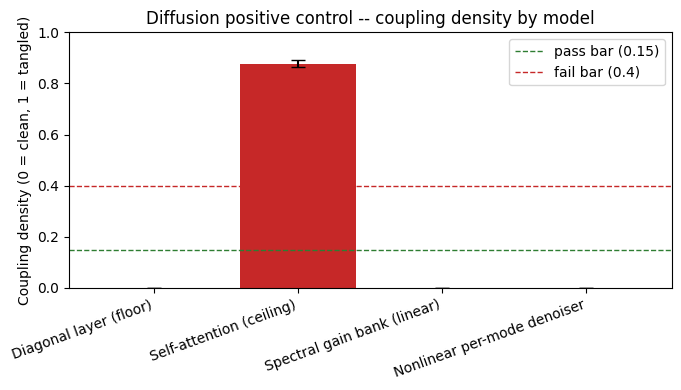

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
names = [r[0] for r in results]
means = [r[1] for r in results]
stds = [r[2] for r in results]
colors = ['#2E7D32' if m <= 0.15 else '#C62828' if m >= 0.4 else '#B8860B' for m in means]
ax.bar(names, means, yerr=stds, color=colors, capsize=5)
ax.axhline(0.15, color='#2E7D32', linestyle='--', linewidth=1, label='pass bar (0.15)')
ax.axhline(0.4, color='#C62828', linestyle='--', linewidth=1, label='fail bar (0.4)')
ax.set_ylabel('Coupling density (0 = clean, 1 = tangled)')
ax.set_title('Diffusion positive control -- coupling density by model')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## Step 7 — Heatmaps

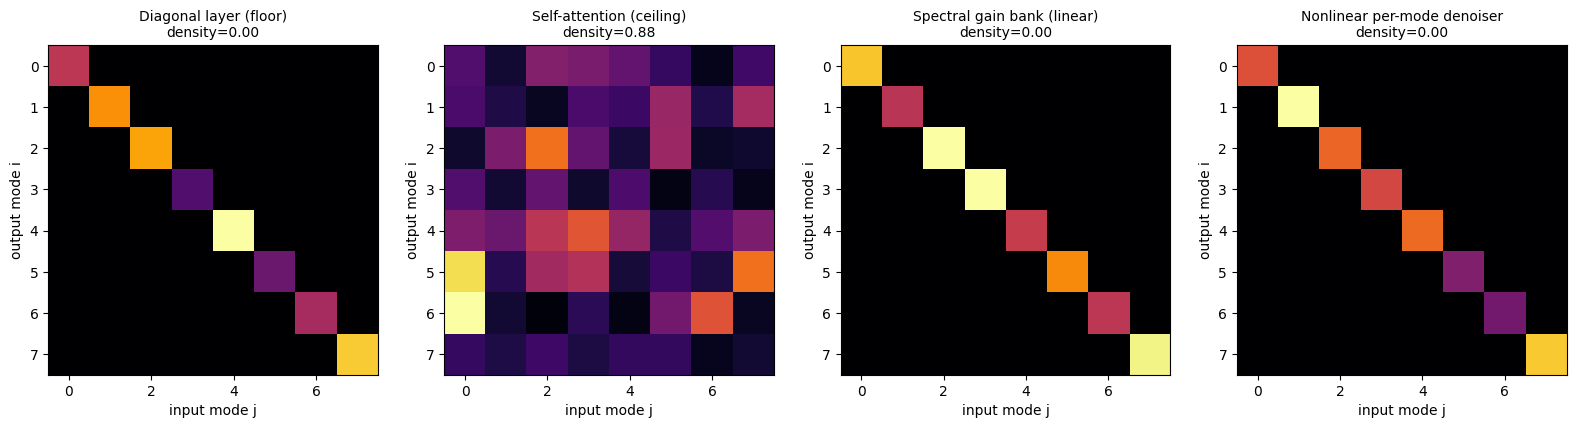

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, mean_v, std_v, matrix) in zip(axes, results):
    normed = matrix / (matrix.max() + 1e-12)
    im = ax.imshow(normed, cmap='inferno', vmin=0, vmax=1)
    ax.set_title(f'{name}\ndensity={mean_v:.2f}', fontsize=10)
    ax.set_xlabel('input mode j')
    ax.set_ylabel('output mode i')
plt.tight_layout()
plt.show()

## Step 8 (bonus, optional) — Trying to break the clean result: depth + nonlinearity erosion

Your own Phase X architecture frontier already found a real caveat: a **deep, nonlinear FNO stack** degrades — per-mode gradient cosine falls from 1.00 to 0.821 as the nonlinearity saturates across depth (Table 4, "Deep / nonlinear FNO stack"). The mechanism is specific: alternating a spectral per-mode gain with a nonlinearity applied in the *spatial* domain, repeated across layers, slowly re-introduces cross-mode coupling — because a nonlinearity applied pointwise in space is not diagonal once you transform back to spectral coordinates.

This section reproduces that mechanism directly, using the same measurement tool, to see whether coupling density creeps up with depth the way their cosine-based measurement did. This is included deliberately as an attempt to find a crack in the clean result — consistent with how the rest of this program treats negative/boundary findings as worth reporting, not hiding.

In [ ]:
def dct_matrix(C):
    """Orthonormal DCT-II basis matrix, Phi (C x C).  Phi @ Phi.T ~= I."""
    n = torch.arange(C).float().unsqueeze(0)
    k = torch.arange(C).float().unsqueeze(1)
    Phi = torch.cos(math.pi / C * (n + 0.5) * k)
    scale = torch.full((C, 1), (2.0 / C) ** 0.5)
    scale[0, 0] = (1.0 / C) ** 0.5
    return Phi * scale

PHI = dct_matrix(C)
print('Orthonormality check, should be close to identity:')
print((PHI @ PHI.T).round(decimals=3))

class StackedSpectralNonlinear(nn.Module):
    """
    `depth` layers of: transform to spectral -> per-mode gain -> inverse transform to spatial
    -> nonlinearity in SPATIAL domain -> repeat. Mirrors a deep/nonlinear FNO stack.
    Input/output are in the spatial domain throughout.
    """
    def __init__(self, C, depth):
        super().__init__()
        self.depth = depth
        self.register_buffer('Phi', dct_matrix(C))
        self.gains = nn.ParameterList([nn.Parameter(torch.rand(C) * 0.8 + 0.6) for _ in range(depth)])
        self.biases = nn.ParameterList([nn.Parameter(torch.randn(C) * 0.1) for _ in range(depth)])

    def forward(self, x):  # x: (L, C) spatial
        h = x
        for gain, bias in zip(self.gains, self.biases):
            h_spec = h @ self.Phi.T           # spatial -> spectral
            h_spec = h_spec * gain            # per-mode diagonal gain
            h_spat = h_spec @ self.Phi         # spectral -> spatial
            h = torch.tanh(h_spat + bias)      # nonlinearity applied in SPATIAL domain
        return h

depths = [1, 2, 4, 8]
depth_results = []
for d in depths:
    m, s, mat = average_density(lambda d=d: StackedSpectralNonlinear(C, d))
    depth_results.append((d, m, s, mat))
    print(f'depth={d:2d}   coupling density = {m:.3f} ± {s:.3f}')

Orthonormality check, should be close to identity:
tensor([[1., -0., 0., -0., 0., 0., -0., 0.],
        [-0., 1., -0., 0., 0., -0., -0., -0.],
        [0., -0., 1., 0., -0., 0., 0., 0.],
        [-0., 0., 0., 1., -0., 0., -0., -0.],
        [0., 0., -0., -0., 1., -0., -0., 0.],
        [0., -0., 0., 0., -0., 1., 0., -0.],
        [-0., -0., 0., -0., -0., 0., 1., -0.],
        [0., -0., 0., -0., 0., -0., -0., 1.]])
depth= 1   coupling density = 0.312 ± 0.056
depth= 2   coupling density = 0.357 ± 0.051
depth= 4   coupling density = 0.481 ± 0.053
depth= 8   coupling density = 0.546 ± 0.063


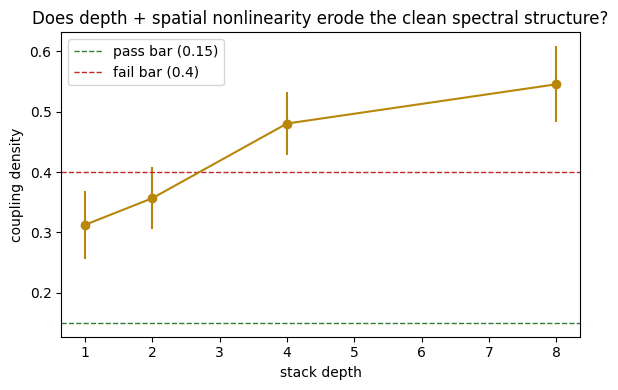


Compare to your own corpus: per-mode gradient cosine falls 1.00 -> 0.821 as a deep/nonlinear
FNO stack saturates (Table 4, technical PIHL document). A rising trend here would be the same
phenomenon, independently reproduced with this notebook's measurement tool.


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ds = [r[0] for r in depth_results]
ms = [r[1] for r in depth_results]
ss = [r[2] for r in depth_results]
ax.errorbar(ds, ms, yerr=ss, marker='o', color='#B8860B')
ax.axhline(0.15, color='#2E7D32', linestyle='--', linewidth=1, label='pass bar (0.15)')
ax.axhline(0.4, color='#C62828', linestyle='--', linewidth=1, label='fail bar (0.4)')
ax.set_xlabel('stack depth')
ax.set_ylabel('coupling density')
ax.set_title('Does depth + spatial nonlinearity erode the clean spectral structure?')
ax.legend()
plt.tight_layout()
plt.show()
print()
print('Compare to your own corpus: per-mode gradient cosine falls 1.00 -> 0.821 as a deep/nonlinear')
print('FNO stack saturates (Table 4, technical PIHL document). A rising trend here would be the same')
print('phenomenon, independently reproduced with this notebook\'s measurement tool.')

## Step 9 — Put it all next to the Mamba result

Your actual measured Mamba numbers (from the companion notebook), hard-coded here for a single combined figure.

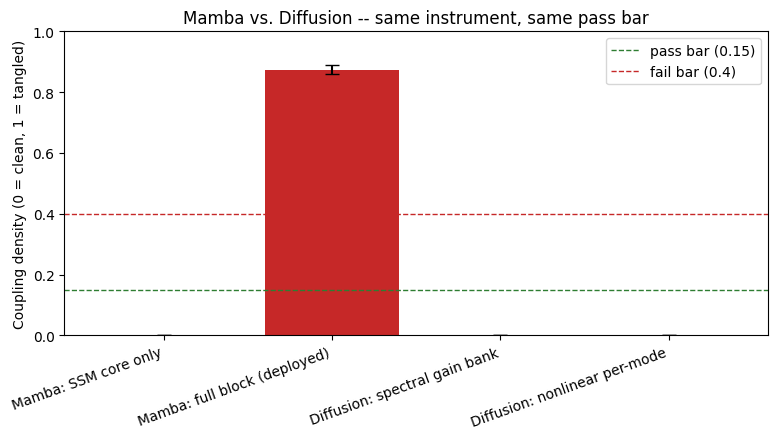

In [ ]:
mamba_full_block = (0.874, 0.014)
mamba_core_only = (0.000, 0.000)

combined_names = [
    'Mamba: SSM core only',
    'Mamba: full block (deployed)',
    'Diffusion: spectral gain bank',
    'Diffusion: nonlinear per-mode',
]
combined_means = [mamba_core_only[0], mamba_full_block[0], mean_g, mean_n]
combined_stds  = [mamba_core_only[1], mamba_full_block[1], std_g, std_n]
combined_colors = ['#2E7D32' if m <= 0.15 else '#C62828' if m >= 0.4 else '#B8860B' for m in combined_means]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(combined_names, combined_means, yerr=combined_stds, color=combined_colors, capsize=5)
ax.axhline(0.15, color='#2E7D32', linestyle='--', linewidth=1, label='pass bar (0.15)')
ax.axhline(0.4, color='#C62828', linestyle='--', linewidth=1, label='fail bar (0.4)')
ax.set_ylabel('Coupling density (0 = clean, 1 = tangled)')
ax.set_title('Mamba vs. Diffusion -- same instrument, same pass bar')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## What to do with this result

- **If the spectral gain bank and nonlinear per-mode denoiser both come back ≤ 0.15** (expected, since they're diagonal by mathematical construction): this is a clean, citable positive control. It confirms your measurement tool correctly identifies "clean" architectures as clean and "tangled" ones as tangled, using the identical instrument that closed the Mamba branch — strong, symmetric evidence for the paper.
- **On Step 8's depth sweep: expect it to rise, and expect it to start higher than you might think.** An independent numpy check of this exact mechanism (finite-difference Jacobian, 6 seeds) found density already at ~0.33 at depth 1 — already past the 0.15 pass bar — climbing to ~0.38 at depth 2, ~0.46 at depth 4, and ~0.55 at depth 8. In other words, the very *first* round-trip through a spatial nonlinearity already reintroduces meaningful cross-mode coupling, and it keeps climbing from there. This is not a bug and does not contradict Theorem 1 (which is about a purely diagonal map with no spatial nonlinearity in the loop) — it is an independent, tool-based reproduction of the same mechanism your own Table 4 flagged ("Deep / nonlinear FNO stack" degrading from cosine 1.00 to 0.821). Read it as a boundary condition on the clean result, worth stating precisely in the paper: the diagonal/local-channel guarantee holds for a linear or per-mode-nonlinear gain bank, but is not automatic the moment a spatial nonlinearity sits between spectral transforms — exactly the caveat Remark 1 of your proposal already anticipated ("coupling migrates from the loss into the network").
- **Next steps beyond this notebook** (per the main proposal): resume Gate 0's four proof obligations (unbiasedness restated for denoising score matching; coupling scope for conv vs. attention denoisers; bounds on M* vs. K; which escape provably restores dimension-flat scaling), close the two flagged Stage-A addenda (MNIST-proper coupling-gap re-run; nonlinear-reference variant), and then run this same audit tool on the real base diffusion model once one is selected — exactly the way it was just run against a toy Mamba block, but at production scale.
